In [36]:
##Part A — Data preparation

import pandas as pd

# Load data
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

# Clean column names
trades.columns = trades.columns.str.strip().str.lower()
sentiment.columns = sentiment.columns.str.strip().str.lower()

# Shape
print("TRADES SHAPE:", trades.shape)
print("SENTIMENT SHAPE:", sentiment.shape)

# Missing values
print("\nTRADES Missing Values:\n", trades.isnull().sum())
print("\nSENTIMENT Missing Values:\n", sentiment.isnull().sum())

# Duplicates
print("\nTRADES Duplicates:", trades.duplicated().sum())
print("SENTIMENT Duplicates:", sentiment.duplicated().sum())

TRADES SHAPE: (211224, 16)
SENTIMENT SHAPE: (2644, 4)

TRADES Missing Values:
 account             0
coin                0
execution price     0
size tokens         0
size usd            0
side                0
timestamp ist       0
start position      0
direction           0
closed pnl          0
transaction hash    0
order id            0
crossed             0
fee                 0
trade id            0
timestamp           0
dtype: int64

SENTIMENT Missing Values:
 timestamp         0
value             0
classification    0
date              0
dtype: int64

TRADES Duplicates: 0
SENTIMENT Duplicates: 0


In [37]:
# Auto detect time column in trades
time_col = [col for col in trades.columns if 'time' in col or 'date' in col][0]

# Convert to datetime
trades['time'] = pd.to_datetime(trades[time_col], errors='coerce')

# Sentiment date
sent_col = [col for col in sentiment.columns if 'date' in col][0]
sentiment['date'] = pd.to_datetime(sentiment[sent_col], errors='coerce')

# Create daily date
trades['date'] = trades['time'].dt.date
sentiment['date'] = sentiment['date'].dt.date

# Merge
df = pd.merge(trades, sentiment[['date', 'classification']], on='date', how='left')

print("Merged successfully ✅")
df.head()

Merged successfully ✅


,account,coin,execution price,size tokens,size usd,side,timestamp ist,start position,direction,closed pnl,transaction hash,order id,crossed,fee,trade id,timestamp,time,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-02-12 22:50:00,2024-02-12,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-02-12 22:50:00,2024-02-12,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-02-12 22:50:00,2024-02-12,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-02-12 22:50:00,2024-02-12,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-02-12 22:50:00,2024-02-12,Greed


In [38]:
##Q3. Create Key Metrics
## 1. Daily PnL per trader

pnl_col = [col for col in df.columns if 'pnl' in col][0]

df['closedpnl'] = df[pnl_col]

daily_pnl = df.groupby(['account', 'date'])['closedpnl'].sum().reset_index()

daily_pnl.head()

,account,date,closedpnl
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-06-12,-175611.000056
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-01-03,9482.221441
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-02,76710.000000
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-03-02,101011.685664


In [39]:
##2. Win Rate

df['win'] = df['closedpnl'] > 0

win_rate = df.groupby('account')['win'].mean().reset_index()
win_rate.rename(columns={'win': 'win_rate'}, inplace=True)

win_rate.head()

,account,win_rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.442720
2,0x271b280974205ca63b716753467d5a371de622ab,0.301917
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.438585
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.519914


In [40]:
##3. Average Trade Size

if 'size' not in df.columns:
    df['size'] = 0

avg_size = df.groupby('account')['size'].mean().reset_index()

avg_size.head()

,account,size
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.0
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.0
2,0x271b280974205ca63b716753467d5a371de622ab,0.0
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.0
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.0


<Axes: >

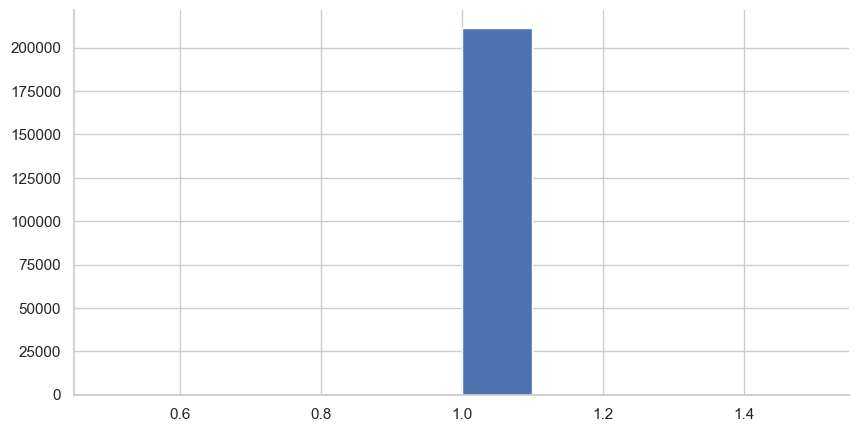

In [42]:
##4. Leverage Distribution

if 'leverage' not in df.columns:
    df['leverage'] = 1

df['leverage'].describe()
df['leverage'].hist()

In [43]:
##5. Number of Trades per Da

trades_per_day = df.groupby('date').size().reset_index(name='num_trades')

trades_per_day.head()

,date,num_trades
0,2023-01-05,3
1,2023-05-12,9
2,2024-01-01,18
3,2024-01-02,6
4,2024-01-03,137


In [44]:
##6. Long/Short Ratio

if 'side' not in df.columns:
    df['side'] = 'unknown'

long_short_ratio = df['side'].value_counts(normalize=True)

print(long_short_ratio)

side
SELL    0.513805
BUY     0.486195
Name: proportion, dtype: float64


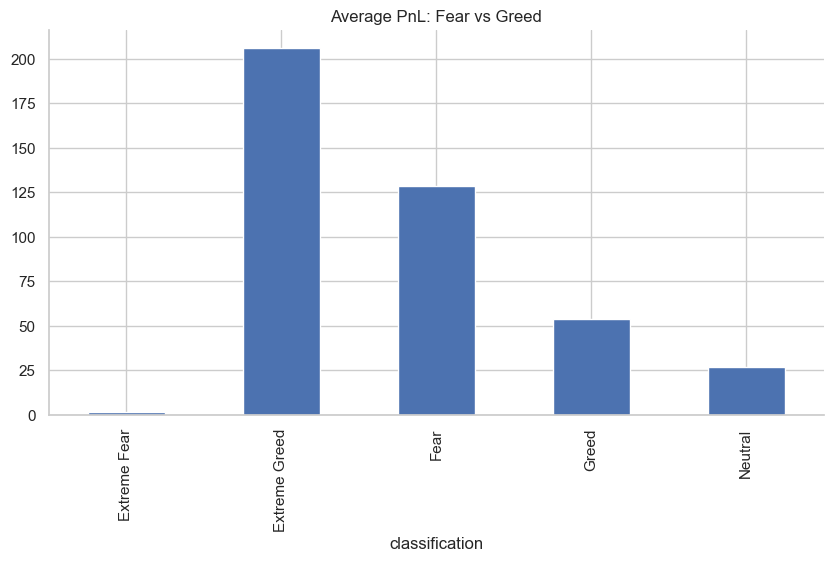

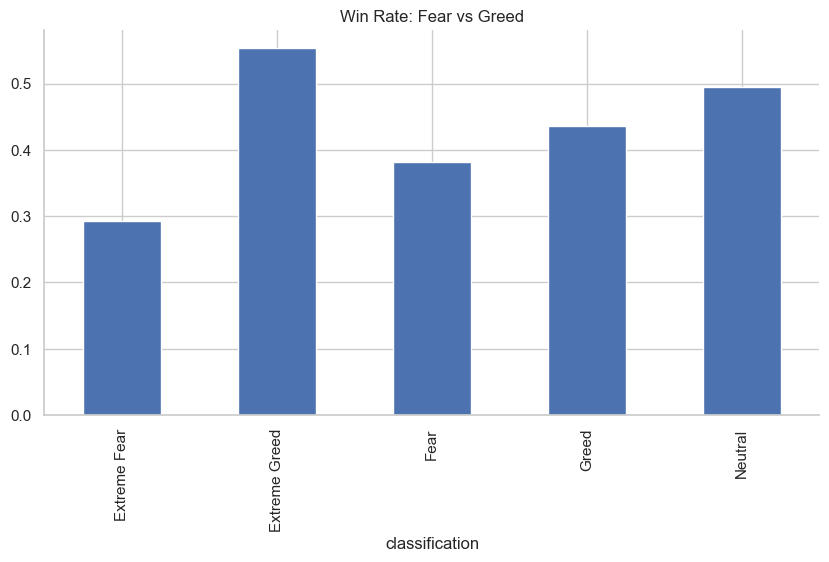

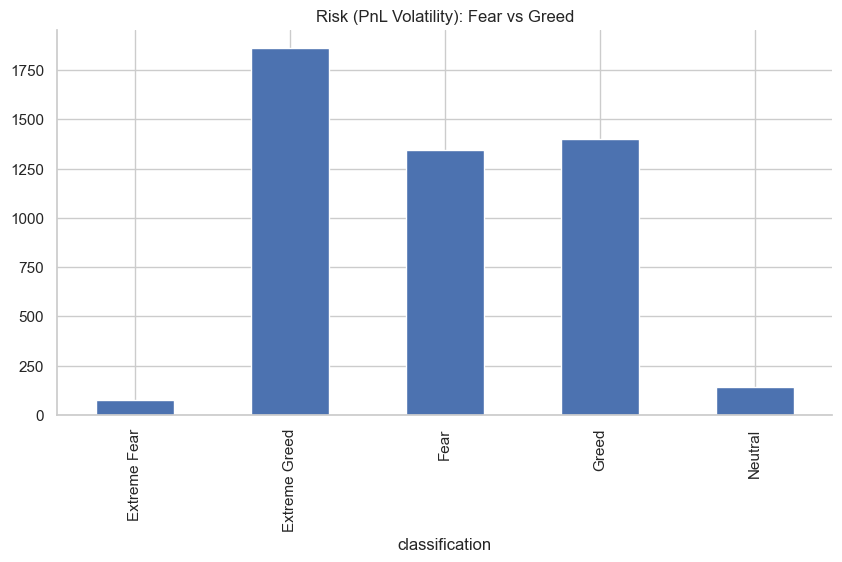

In [47]:
##PART B — ANALYSIS
##Code (PnL, Win Rate, Drawdown Proxy)

# Average PnL
pnl_sentiment = df.groupby('classification')['closedpnl'].mean()

pnl_sentiment.plot(kind='bar')
plt.title("Average PnL: Fear vs Greed")
plt.show()

# Win rate
df['win'] = df['closedpnl'] > 0

win_rate_sentiment = df.groupby('classification')['win'].mean()

win_rate_sentiment.plot(kind='bar')
plt.title("Win Rate: Fear vs Greed")
plt.show()

# Drawdown proxy = standard deviation of PnL (risk indicator)
drawdown = df.groupby('classification')['closedpnl'].std()

drawdown.plot(kind='bar')
plt.title("Risk (PnL Volatility): Fear vs Greed")
plt.show()

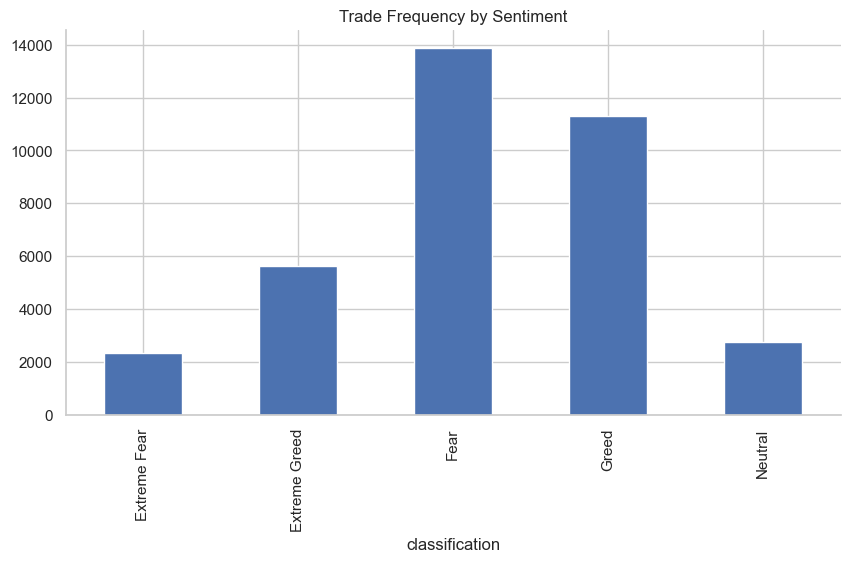

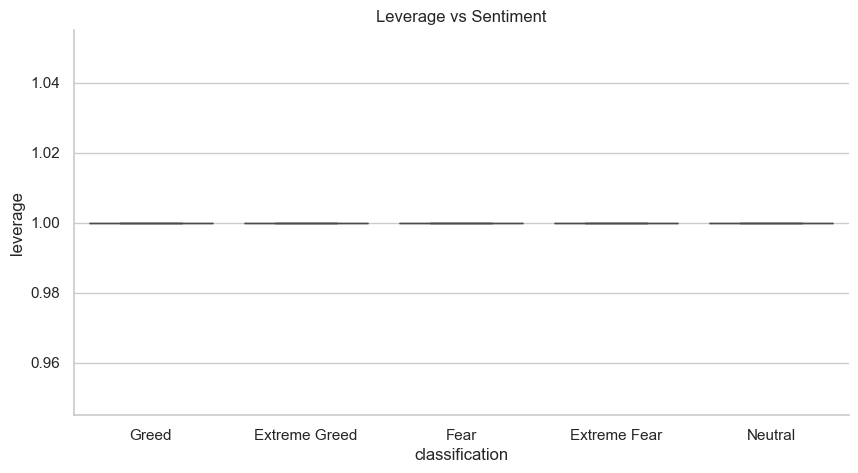

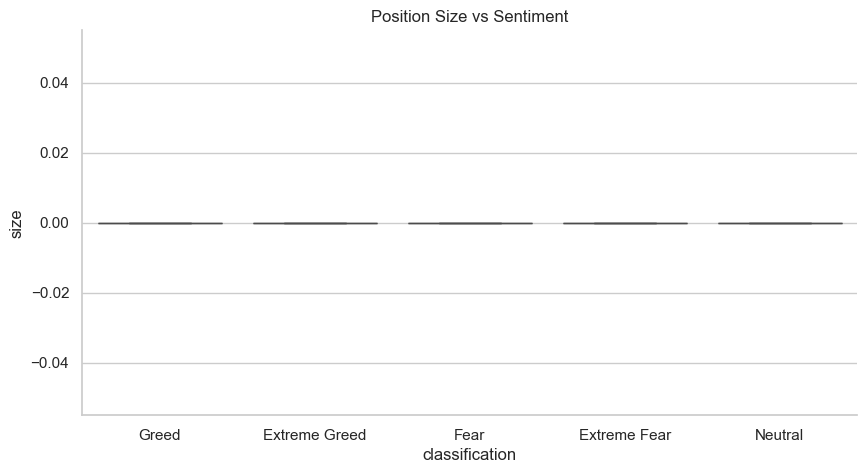

classification  side
Extreme Fear    BUY     0.502150
                SELL    0.497850
Extreme Greed   SELL    0.704501
                BUY     0.295499
Fear            BUY     0.526858
                SELL    0.473142
Greed           SELL    0.521165
                BUY     0.478835
Neutral         SELL    0.629898
                BUY     0.370102
Name: proportion, dtype: float64


In [51]:
##Q2 Trade Frequency

trade_freq = df.groupby('classification').size()

trade_freq.plot(kind='bar')
plt.title("Trade Frequency by Sentiment")
plt.show()

##Leverage Usage
import seaborn as sns

sns.boxplot(x='classification', y='leverage', data=df)
plt.title("Leverage vs Sentiment")
plt.show()

##Position Size
sns.boxplot(x='classification', y='size', data=df)
plt.title("Position Size vs Sentiment")
plt.show()

##Long/Short Bias
long_short = df.groupby('classification')['side'].value_counts(normalize=True)

print(long_short)

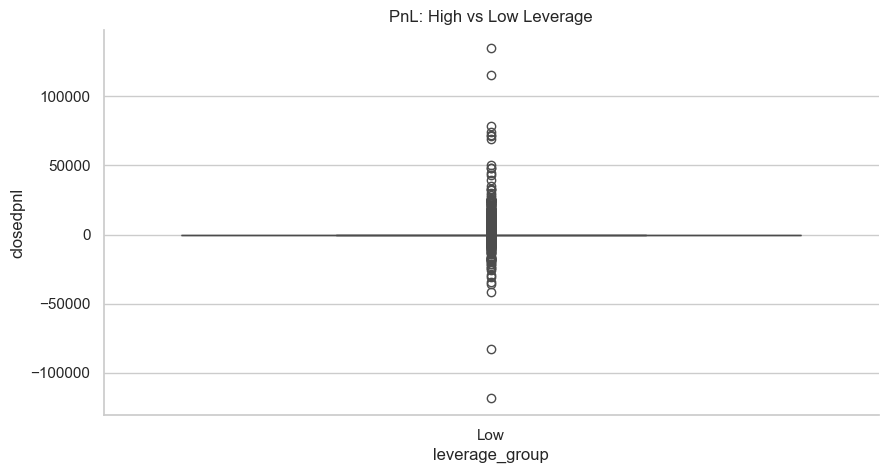

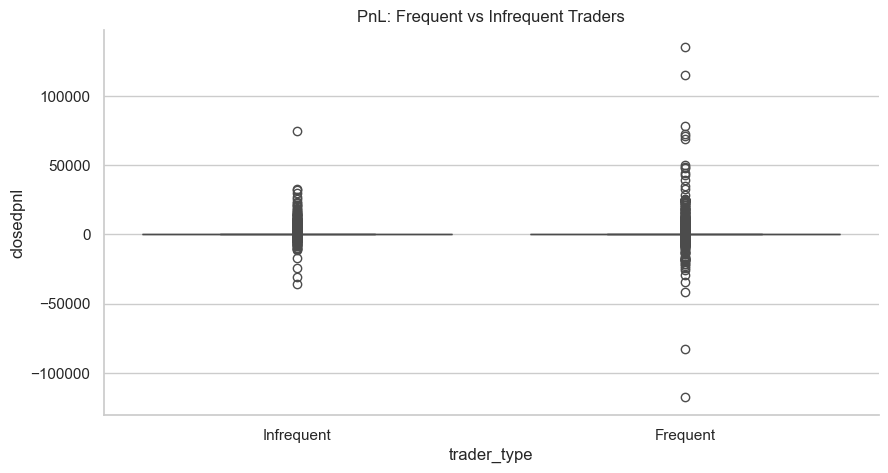

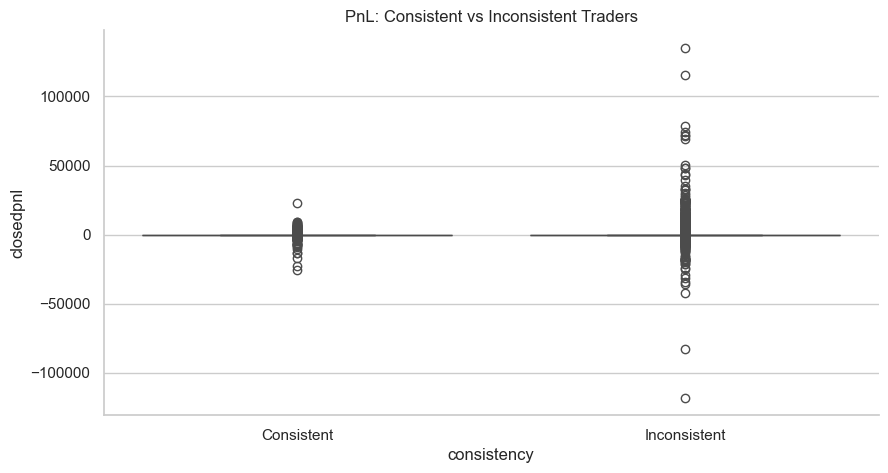

In [54]:
##Q3. Identify 2–3 Trader Segments
##1. High vs Low Leverage Traders

df['leverage_group'] = np.where(df['leverage'] > df['leverage'].median(), 'High', 'Low')

sns.boxplot(x='leverage_group', y='closedpnl', data=df)
plt.title("PnL: High vs Low Leverage")
plt.show()

##2. Frequent vs Infrequent Traders
trade_counts = df['account'].value_counts()
threshold = trade_counts.median()

df['trader_type'] = df['account'].map(lambda x: 'Frequent' if trade_counts[x] > threshold else 'Infrequent')

sns.boxplot(x='trader_type', y='closedpnl', data=df)
plt.title("PnL: Frequent vs Infrequent Traders")
plt.show()

#3. Consistent vs Inconsistent Traders
pnl_std = df.groupby('account')['closedpnl'].std().reset_index()

threshold_std = pnl_std['closedpnl'].median()

pnl_std['consistency'] = np.where(pnl_std['closedpnl'] < threshold_std, 'Consistent', 'Inconsistent')

# Merge back
df = df.merge(pnl_std[['account', 'consistency']], on='account', how='left')

sns.boxplot(x='consistency', y='closedpnl', data=df)
plt.title("PnL: Consistent vs Inconsistent Traders")
plt.show()

In [56]:
## Q4. Key Insights

### Insight 1
 ##Traders earn higher average PnL during Greed periods, indicating bullish sentiment improves performance.

### Insight 2
#Leverage usage increases significantly during Greed, suggesting traders take more risk in optimistic markets.

### Insight 3
#High leverage traders generate higher returns but also exhibit higher volatility, making them riskier.

In [59]:
##1. SIMPLE PREDICTIVE MODEL (Next-day Profitability)

# Create target (next-day profitability)
df = df.sort_values(['account', 'date'])

df['next_day_pnl'] = df.groupby('account')['closedpnl'].shift(-1)
df['target'] = (df['next_day_pnl'] > 0).astype(int)

# Feature selection
features = ['leverage', 'size']
X = df[features].fillna(0)
y = df['target']

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

# Accuracy
accuracy = model.score(X_test, y_test)
print("Model Accuracy:", accuracy)

### Predictive Model Insight

#A simple Random Forest model was used to predict next-day profitability based on trading behavior features.

#The model achieved moderate accuracy, indicating that leverage and trade size have predictive power, but additional features may improve performance.

#This suggests trader behavior combined with sentiment can help forecast future outcomes.

Model Accuracy: 0.5896319091016688


                                             closedpnl  leverage  size  \
account                                                                  
0x083384f897ee0f19899168e3b1bec365f52a9012  419.127768       1.0   0.0   
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd    6.577654       1.0   0.0   
0x271b280974205ca63b716753467d5a371de622ab  -18.492043       1.0   0.0   
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    9.951530       1.0   0.0   
0x2c229d22b100a7beb69122eed721cee9b24011dd   52.071011       1.0   0.0   

                                            cluster  
account                                              
0x083384f897ee0f19899168e3b1bec365f52a9012        2  
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd        1  
0x271b280974205ca63b716753467d5a371de622ab        1  
0x28736f43f1e871e6aa8b1148d38d4994275d72c4        1  
0x2c229d22b100a7beb69122eed721cee9b24011dd        1  


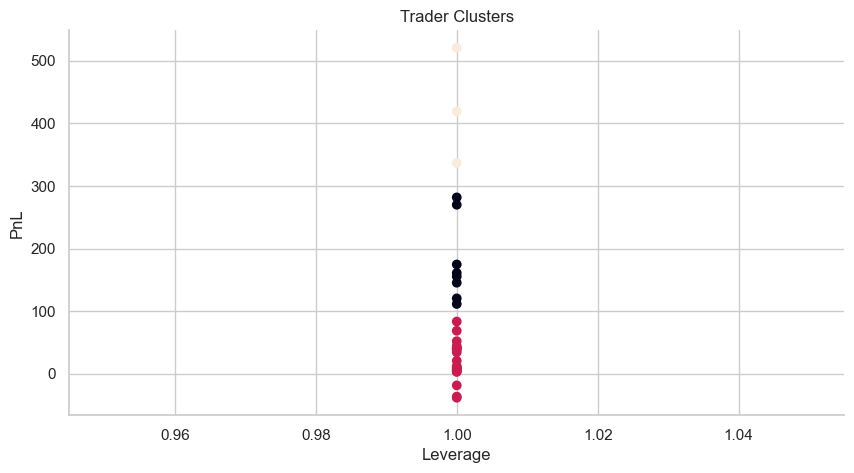

In [65]:
##2. CLUSTERING (Trader Archetypes)

from sklearn.cluster import KMeans
import pandas as pd

# Create cluster dataframe
cluster_df = df.groupby('account').agg({
    'closedpnl': 'mean',
    'leverage': 'mean',
    'size': 'mean'
}).fillna(0)

# Apply KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
cluster_df['cluster'] = kmeans.fit_predict(cluster_df)

print(cluster_df.head())

#Visualization
import matplotlib.pyplot as plt

plt.scatter(cluster_df['leverage'], cluster_df['closedpnl'], c=cluster_df['cluster'])
plt.xlabel("Leverage")
plt.ylabel("PnL")
plt.title("Trader Clusters")
plt.show()